In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
#EDA
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
df.species.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

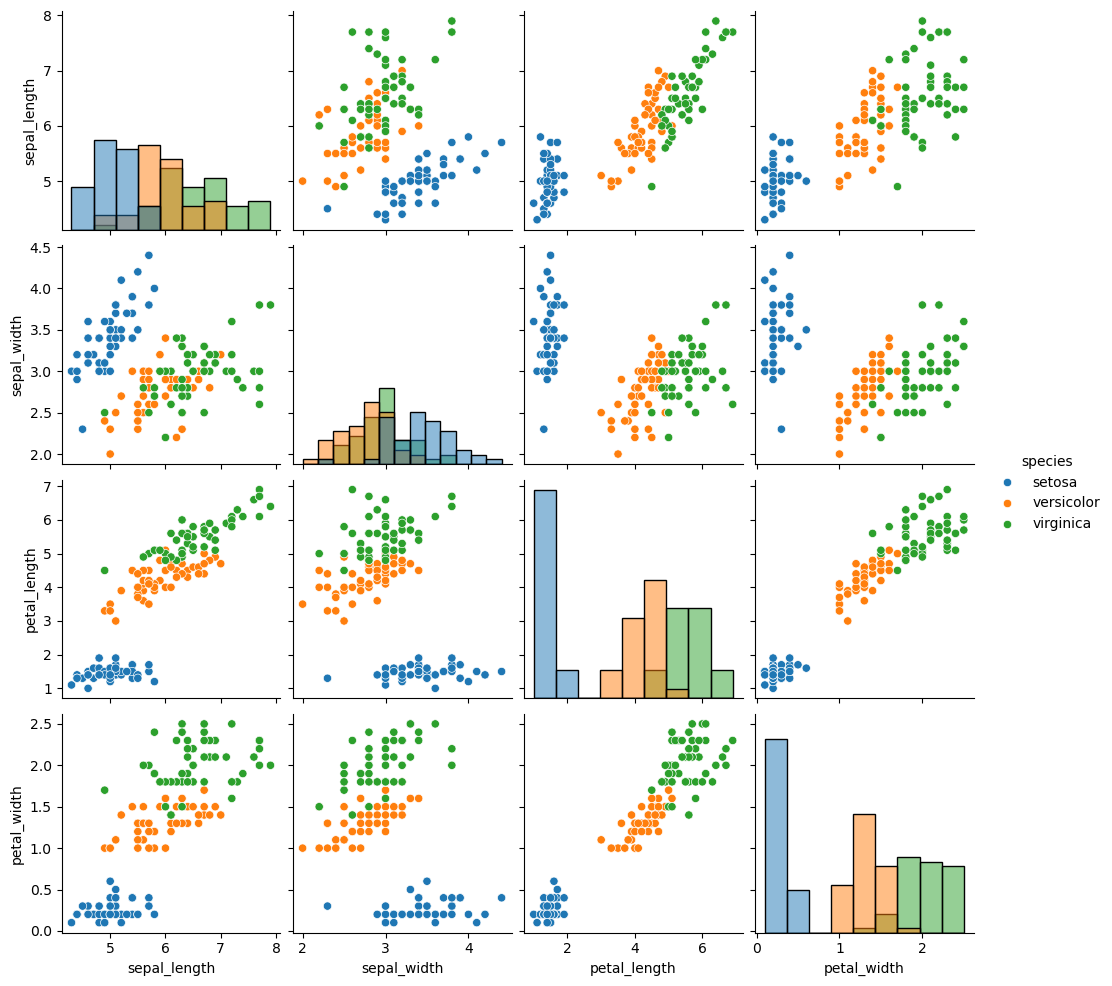

In [6]:
sns.pairplot(df,hue='species',diag_kind='hist')

<Axes: xlabel='species', ylabel='petal_width'>

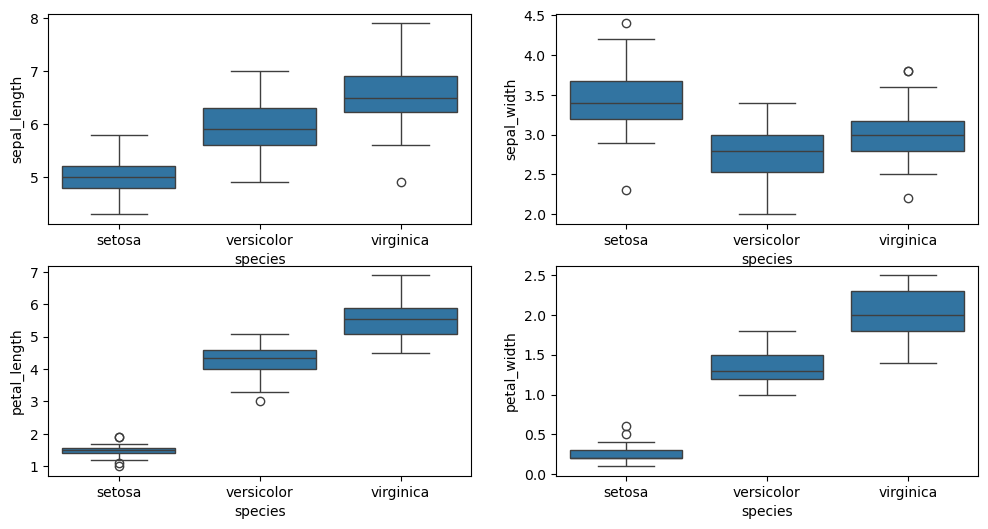

In [9]:
fig,ax=plt.subplots(2,2,figsize=(12,6))
sns.boxplot(x=df['species'],y=df['sepal_length'],ax=ax[0][0])
sns.boxplot(x=df['species'],y=df['sepal_width'],ax=ax[0][1])
sns.boxplot(x=df['species'],y=df['petal_length'],ax=ax[1][0])
sns.boxplot(x=df['species'],y=df['petal_width'],ax=ax[1][1])

In [10]:
#Features and target
x=df[['petal_length','petal_width']]
species_to_num={'setosa':0,'versicolor':1,'virginica':2}
df['tmp']=df['species'].map(species_to_num)
y=df['tmp']

In [15]:
#train & test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=0)

In [16]:
#feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_std=sc.fit_transform(x_train)
x_train_std

array([[ 0.94751783,  0.736072  ],
       [ 0.38491447,  0.34752959],
       [-1.30289562, -1.33615415],
       [ 0.60995581,  0.736072  ],
       [ 1.00377816,  1.25412853],
       [ 0.04735245,  0.21801546],
       [-1.19037495, -1.20664002],
       [ 0.72247648,  0.47704373],
       [ 0.21613346,  0.34752959],
       [ 0.10361279, -0.04101281],
       [ 0.94751783,  1.1246144 ],
       [-1.41541629, -1.33615415],
       [ 0.72247648,  1.38364267],
       [-1.24663528, -0.81809761],
       [-1.30289562, -1.33615415],
       [-0.1776889 , -0.30004108],
       [ 0.94751783,  0.736072  ],
       [ 1.0600385 ,  1.64267094],
       [ 0.66621615,  0.34752959],
       [ 1.11629884,  0.736072  ],
       [ 0.04735245, -0.17052694],
       [ 1.28507985,  1.38364267],
       [ 0.49743514,  0.47704373],
       [-0.00890789, -0.17052694],
       [ 0.60995581,  0.736072  ],
       [ 0.72247648,  0.34752959],
       [ 0.38491447,  0.60655786],
       [ 0.66621615,  0.86558613],
       [ 0.49743514,

In [35]:
#Build model
from sklearn import svm
C=1   #0.001
svm_clf=svm.SVC(kernel='linear',C=C)
#svm_clf=svm.SVC(kernel='poly',degree=3,C=C,gamma='auto')
svm_clf=svm.SVC(kernel='rbf',C=C,gamma=0.1)
svm_clf.fit(x_train_std,y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [36]:
#Standardize x_test
x_test_std=sc.transform(x_test)
x_test_std


array([[ 0.72247648,  1.5131568 ],
       [ 0.10361279, -0.30004108],
       [-1.35915595, -1.33615415],
       [ 1.39760052,  0.736072  ],
       [-1.30289562, -1.33615415],
       [ 1.22881951,  1.64267094],
       [-1.41541629, -1.20664002],
       [ 0.49743514,  0.34752959],
       [ 0.55369548,  0.21801546],
       [ 0.10361279,  0.08850133],
       [ 1.00377816,  0.21801546],
       [ 0.38491447,  0.34752959],
       [ 0.49743514, -0.04101281],
       [ 0.4411748 ,  0.34752959],
       [ 0.49743514,  0.21801546],
       [-1.35915595, -1.46566829],
       [ 0.38491447,  0.34752959],
       [ 0.32865413, -0.04101281],
       [-1.35915595, -1.20664002],
       [-1.41541629, -1.07712588],
       [ 0.60995581,  0.99510027],
       [ 0.38491447,  0.34752959],
       [-1.07785427, -1.33615415],
       [-1.35915595, -1.33615415],
       [ 0.55369548,  0.736072  ],
       [-1.5841973 , -1.33615415],
       [-1.07785427, -1.07712588],
       [ 0.27239379,  0.08850133],
       [-0.29020957,

In [37]:
y_test_pred=svm_clf.predict(x_test_std)
y_test_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

In [38]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [39]:
accuracy_score(y_test,y_test_pred)


1.0

In [40]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [41]:
confusion_matrix(y_test,y_test_pred)

array([[11,  0,  0],
       [ 0, 13,  0],
       [ 0,  0,  6]])

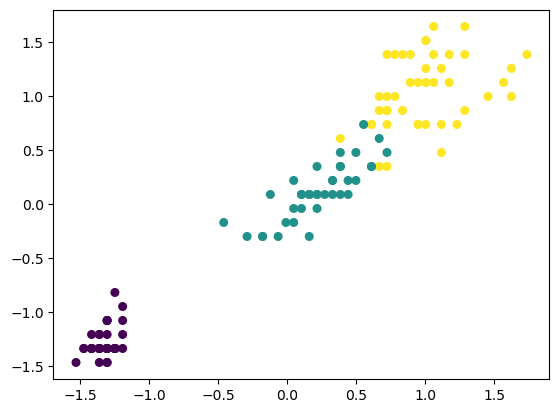

In [47]:
#plot support vector
support_vectors=svm_clf.support_vectors_
support_vectors
plt.scatter(x_train_std[:,0],x_train_std[:,1],c=y_train,s=30)


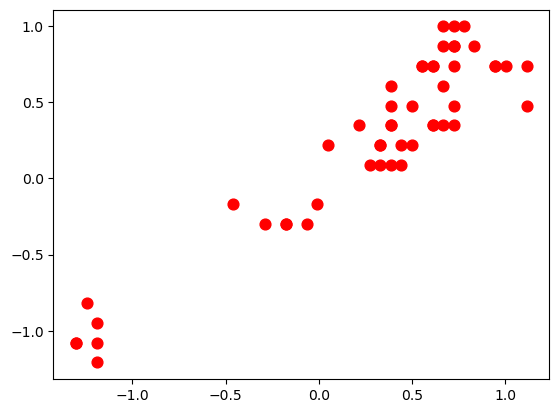

In [46]:
plt.scatter(support_vectors[:,0],support_vectors[:,1],color='red',s=60)